# **Flood Mapping using Sentinel-2 Satellite Imagery**


# Install Libraries
## Uncomment below if using Github

In [ ]:
#!wget https://github.com/Munazaa/Flood-Mapping-Case/raw/main/requirements.txt

In [ ]:
#!pip install -r requirements.txt

In [10]:
!pip install rasterio numpy geopandas matplotlib shapely pillow contextily

In [19]:
# Import Libraries
import glob
import os
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio import features
from rasterio.features import shapes
from shapely.geometry import shape
from PIL import Image
import os
from rasterio import features
import geopandas as gpd
from rasterio.mask import mask
import zipfile
import contextily as ctx
import logging
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from pathlib import Path

## User defined Config

In [12]:

# === CONFIG: Set This Per Event ===

aoi_name = 'Garda'
# Date ranges
BEFORE_EVENT_START = "2020-09-10"
BEFORE_EVENT_END = "2020-10-01"
AFTER_EVENT_START = "2020-10-02"
AFTER_EVENT_END = "2020-10-15"
aoi_path = Path('/content/drive/MyDrive/AIxPA (Demo Code)/AOI_TEST/AOI_Rec.shp')  # AOI shapefile
pre_flood_folder = "/content/drive/MyDrive/AIxPA (Demo Code)/Flood_layers-Munazza/Sentinel-2(Pre-NDWI)"
post_flood_folder = "/content/drive/MyDrive/AIxPA (Demo Code)/Flood_layers-Munazza/Sentinel-2(post-NDWI)"
output_folder = Path('/content/s2_outputs')
output_folder.mkdir(parents=True, exist_ok=True)
mean_ndwi_output = output_folder / 'mean_ndwi_post.tif'  # Mean NDWI TIFF
s2_output_shapefile = output_folder / 'Garda_flood_layer.shp'
s2_output_raster = output_folder / 'Garda_flood_layer.tif'
# Output shapefile path
flood_shapefile = os.path.join(output_folder, f"{aoi_name}_flood_layer.shp")
metadata_output_path = os.path.join(output_folder, f"{aoi_name}_metadata.json")
target_crs = 'EPSG:25832'  # ETRS89 / UTM zone 32N
resolution = 10  # 10m
ndwi_threshold = 0.0  # Adjustable based on NDWI range

# Sentinel-2 Processing

In [13]:
import glob
import os

# Find all NDWI TIFF files in each folder
pre_flood_files = sorted(glob.glob(os.path.join(pre_flood_folder, "*.tif")))
post_flood_files = sorted(glob.glob(os.path.join(post_flood_folder, "*.tif")))

# Print the count only
print(f" Found {len(pre_flood_files)} pre-flood images.")
print(f" Found {len(post_flood_files)} post-flood images.")


 Found 3 pre-flood images.
 Found 3 post-flood images.


In [14]:
# Read and print CRS for each image
print("Pre-flood CRS:")
for f in pre_flood_files:
    with rasterio.open(f) as src:
        print(f" - {os.path.basename(f)}: {src.crs}")

print("\nPost-flood CRS:")
for f in post_flood_files:
    with rasterio.open(f) as src:
        print(f" - {os.path.basename(f)}: {src.crs}")

Pre-flood CRS:
 - S2A_MSIL2A_20200915T101031_N0500_R022_T32TPS_20230416T031135.SAFE_NDWI.tif: EPSG:32632
 - S2A_MSIL2A_20200918T102031_N0500_R065_T32TPS_20230417T181738.SAFE_NDWI.tif: EPSG:32632
 - S2B_MSIL2A_20200930T100729_N0500_R022_T32TPS_20230420T090422.SAFE_NDWI.tif: EPSG:32632

Post-flood CRS:
 - S2B_MSIL2A_20201010T101029_N0500_R022_T32TPS_20230403T231653.SAFE_NDWI.tif: EPSG:32632
 - S2B_MSIL2A_20201013T101909_N0500_R065_T32TPS_20230408T010251.SAFE_NDWI.tif: EPSG:32632
 - S2B_MSIL2A_20201013T101909_N0500_R065_T32TPS_20230415T003712.SAFE_NDWI.tif: EPSG:32632


In [15]:
# Set up logging
logging.basicConfig(filename='s2_processing.log', level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s')


# Find NDWI TIFF files
pre_flood_files = sorted(glob.glob(os.path.join(pre_flood_folder, "*.tif")))
post_flood_files = sorted(glob.glob(os.path.join(post_flood_folder, "*.tif")))

# Cell 3: Verify Inputs
if not post_flood_files:
    logging.error("No post-flood NDWI files found.")
    raise FileNotFoundError("No post-flood NDWI files found.")
if not aoi_path.exists():
    logging.error("AOI shapefile missing.")
    raise FileNotFoundError("AOI shapefile missing.")
logging.info(f"Pre-flood files: {pre_flood_files}")
logging.info(f"Post-flood files: {post_flood_files}")

# Cell 4: Load Shapefile and Get AOI
def get_aoi_bounds(shapefile):
    """Get bounding box and GeoDataFrame from shapefile in target CRS."""
    try:
        gdf = gpd.read_file(shapefile)
        if not gdf.crs:
            logging.warning("AOI CRS undefined; assuming EPSG:25832")
            gdf.set_crs('EPSG:25832', inplace=True)
        if gdf.crs.to_string() != target_crs:
            logging.warning(f"Reprojecting shapefile to {target_crs}")
            gdf = gdf.to_crs(target_crs)
        bounds = gdf.total_bounds
        logging.info(f"AOI bounds (EPSG:25832): {bounds}")
        return box(bounds[0], bounds[1], bounds[2], bounds[3]), gdf
    except Exception as e:
        logging.error(f"Error reading shapefile: {str(e)}")
        raise

aoi, aoi_gdf = get_aoi_bounds(aoi_path)

# Cell 5: Compute Mean NDWI
def compute_mean_ndwi(files, aoi_gdf):
    """Compute mean NDWI, clipped to AOI, in EPSG:25832."""
    try:
        ndwi_stack = []
        ref_transform = None
        ref_crs = target_crs
        ref_height = None
        ref_width = None

        # Define reference grid from AOI
        aoi_bounds = aoi_gdf.total_bounds
        ref_width = int((aoi_bounds[2] - aoi_bounds[0]) / resolution)
        ref_height = int((aoi_bounds[3] - aoi_bounds[1]) / resolution)
        ref_transform = rasterio.transform.from_bounds(
            aoi_bounds[0], aoi_bounds[1], aoi_bounds[2], aoi_bounds[3], ref_width, ref_height
        )
        logging.info(f"Reference grid (AOI): shape=({ref_height}, {ref_width}), bounds={aoi_bounds}, crs={ref_crs}")

        for file in files:
            with rasterio.open(file) as src:
                src_crs = src.crs or 'EPSG:32632'
                src_bounds = src.bounds
                src_nodata = src.nodata if src.nodata is not None else -9999.0
                logging.info(f"Processing {file}: crs={src_crs}, bounds={src_bounds}, nodata={src_nodata}")

                # Reproject AOI to raster CRS
                aoi_projected = aoi_gdf.to_crs(src_crs)
                aoi_bounds_src = aoi_projected.total_bounds
                logging.info(f"AOI bounds in {src_crs}: {aoi_bounds_src}")

                # Check overlap
                src_box = box(src_bounds.left, src_bounds.bottom, src_bounds.right, src_bounds.top)
                aoi_box = box(aoi_bounds_src[0], aoi_bounds_src[1], aoi_bounds_src[2], aoi_bounds_src[3])
                if not src_box.intersects(aoi_box):
                    logging.warning(f"Skipping {file}: AOI does not overlap with raster extent.")
                    continue

                # Clip raster to AOI
                try:
                    ndwi_cropped, cropped_transform = mask(src, aoi_projected.geometry, crop=True, nodata=src_nodata)
                    ndwi_cropped = ndwi_cropped[0]
                    valid_pixels = ndwi_cropped != src_nodata
                    unique_values = np.unique(ndwi_cropped[valid_pixels]) if np.any(valid_pixels) else []
                    logging.info(f"Clipped {file}: shape={ndwi_cropped.shape}, valid_pixels={np.sum(valid_pixels)}, "
                                 f"unique_values={unique_values}")

                    if not np.any(valid_pixels):
                        logging.warning(f"Clipped {file} has no valid pixels.")
                        continue

                    # Reproject to reference grid (EPSG:25832)
                    output_array = np.full((ref_height, ref_width), src_nodata, dtype=np.float32)
                    reproject(
                        source=ndwi_cropped,
                        destination=output_array,
                        src_transform=cropped_transform,
                        src_crs=src_crs,
                        dst_transform=ref_transform,
                        dst_crs=ref_crs,
                        resampling=Resampling.bilinear,
                        src_nodata=src_nodata,
                        dst_nodata=src_nodata
                    )
                    ndwi_stack.append(output_array)

                except ValueError as e:
                    logging.warning(f"Skipping {file}: {str(e)}")
                    continue

        if not ndwi_stack:
            logging.error("No valid NDWI data after clipping.")
            raise ValueError("No valid NDWI data after clipping.")

        ndwi_stack = np.array(ndwi_stack)
        mean_ndwi = np.nanmean(ndwi_stack, axis=0)
        valid_pixels = mean_ndwi != src_nodata
        unique_values = np.unique(mean_ndwi[valid_pixels]) if np.any(valid_pixels) else []
        logging.info(f"Mean NDWI: shape={mean_ndwi.shape}, valid_pixels={np.sum(valid_pixels)}, "
                     f"min={np.nanmin(mean_ndwi[valid_pixels]) if np.any(valid_pixels) else 'N/A'}, "
                     f"max={np.nanmax(mean_ndwi[valid_pixels]) if np.any(valid_pixels) else 'N/A'}, "
                     f"unique_values={unique_values}")

        return mean_ndwi, ref_transform, ref_crs, ref_height, ref_width
    except Exception as e:
        logging.error(f"Error computing mean NDWI: {str(e)}")
        raise

# Compute mean NDWI for post-flood (pre-flood optional)
ndwi_post, post_transform, post_crs, post_height, post_width = compute_mean_ndwi(post_flood_files, aoi_gdf)
if pre_flood_files:
    ndwi_pre, pre_transform, pre_crs, pre_height, pre_width = compute_mean_ndwi(pre_flood_files, aoi_gdf)

# Cell 6: Save Mean NDWI TIFF
def save_mean_ndwi(ndwi_array, transform, crs, height, width, output_file, nodata=-9999.0):
    """Save mean NDWI as TIFF."""
    try:
        out_meta = {
            'driver': 'GTiff',
            'height': height,
            'width': width,
            'count': 1,
            'dtype': 'float32',
            'crs': crs,
            'transform': transform,
            'nodata': nodata
        }
        with rasterio.open(output_file, 'w', **out_meta) as dst:
            dst.write(ndwi_array, 1)
        logging.info(f"Mean NDWI TIFF saved to {output_file} with CRS: {crs}")
    except Exception as e:
        logging.error(f"Error saving mean NDWI: {str(e)}")
        raise

save_mean_ndwi(ndwi_post, post_transform, post_crs, post_height, post_width, mean_ndwi_output)

# Cell 7: Save S2 Water Layer
def save_water_layer(ndwi_array, transform, output_shapefile, output_raster, raster_crs, nodata=-9999.0, threshold=0):
    """Save water layer as TIFF and shapefile in EPSG:25832."""
    try:
        # Define reference grid from AOI
        aoi_bounds = aoi_gdf.total_bounds
        ref_width = int((aoi_bounds[2] - aoi_bounds[0]) / resolution)
        ref_height = int((aoi_bounds[3] - aoi_bounds[1]) / resolution)
        ref_transform = rasterio.transform.from_bounds(
            aoi_bounds[0], aoi_bounds[1], aoi_bounds[2], aoi_bounds[3], ref_width, ref_height
        )
        ref_crs = 'EPSG:25832'

        # Reproject NDWI to reference grid
        output_ndwi = np.full((ref_height, ref_width), nodata, dtype=np.float32)
        reproject(
            source=ndwi_array,
            destination=output_ndwi,
            src_transform=transform,
            src_crs=raster_crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear,
            src_nodata=nodata,
            dst_nodata=nodata
        )

        # Create water mask
        water_mask = (output_ndwi > threshold).astype(np.uint8)
        valid_pixels = output_ndwi != nodata
        water_pixels = water_mask == 1
        logging.info(f"Water mask: shape=({ref_height}, {ref_width}), valid_pixels={np.sum(valid_pixels)}, "
                     f"water_pixels={np.sum(water_pixels)}")

        # Save TIFF
        with rasterio.open(
            output_raster,
            "w",
            driver="GTiff",
            height=ref_height,
            width=ref_width,
            count=1,
            dtype=water_mask.dtype,
            crs=ref_crs,
            transform=ref_transform,
            nodata=0
        ) as dst:
            dst.write(water_mask, 1)
        logging.info(f"Raster TIFF saved to {output_raster} with CRS: {ref_crs}")

        # Save shapefile
        results = shapes(water_mask, mask=water_mask == 1, transform=ref_transform)
        geometries = [shape(geom) for geom, _ in results]
        if geometries:
            gdf = gpd.GeoDataFrame({'geometry': geometries}, crs=ref_crs)
            gdf.to_file(output_shapefile)
            logging.info(f"Shapefile saved to {output_shapefile} with CRS: {ref_crs}")
        else:
            logging.warning("No water pixels found; shapefile not created.")

    except Exception as e:
        logging.error(f"Error saving water layer: {str(e)}")
        raise

save_water_layer(ndwi_post, post_transform, s2_output_shapefile, s2_output_raster, post_crs, threshold=0.0)

In [16]:

# Find all NDWI TIFF files in each folder
pre_flood_files = sorted(glob.glob(os.path.join(pre_flood_folder, "*.tif")))
post_flood_files = sorted(glob.glob(os.path.join(post_flood_folder, "*.tif")))
# Function to compute the mean NDWI across multiple images
# Load AOI
aoi = gpd.read_file(aoi_path)
def compute_mean_ndwi(files):
    ndwi_stack = []

    for file in files:
        with rasterio.open(file) as src:
            # Reproject AOI to match the raster CRS
            aoi_projected = aoi.to_crs(src.crs)

            try:
                ndwi_cropped, _ = mask(src, aoi_projected.geometry, crop=True)
                ndwi_stack.append(ndwi_cropped[0])  # First band
            except ValueError as e:
                print(f"Skipping {file}: {e}")
                continue  # Skip files that don't overlap with AOI

    ndwi_stack = np.array(ndwi_stack)
    mean_ndwi = np.mean(ndwi_stack, axis=0)

    return mean_ndwi

# Compute mean NDWI for pre-flood and post-flood images
ndwi_pre = compute_mean_ndwi(pre_flood_files)
ndwi_post = compute_mean_ndwi(post_flood_files)


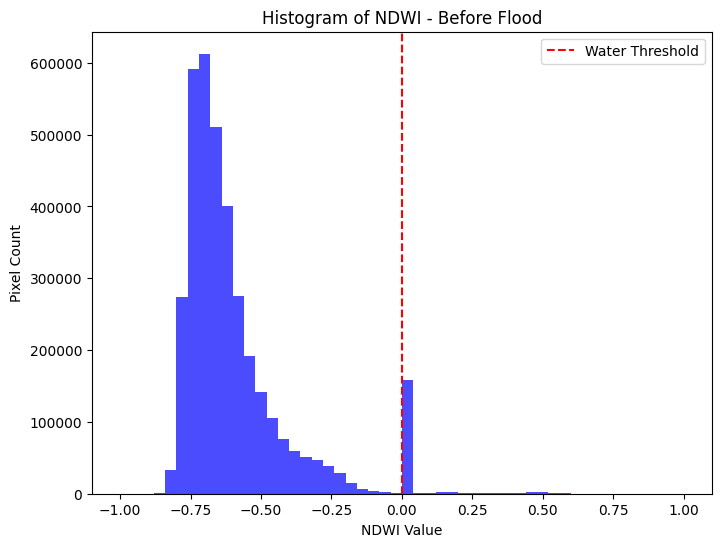

Water area in Before Flood: 0.55%


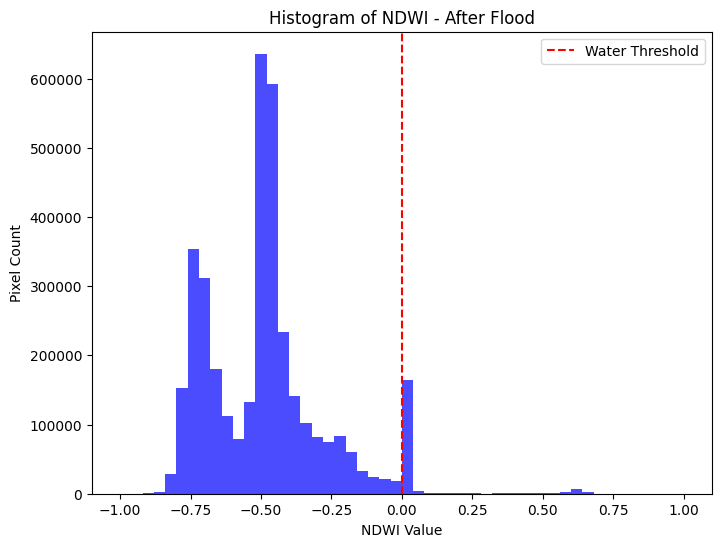

Water area in After Flood: 0.90%


In [17]:
# Function to calculate water pixels and plot histograms
def analyze_water(ndwi_array, title, threshold=0):
    # Classify water pixels based on NDWI threshold
    water_pixels = ndwi_array > threshold
    water_percentage = np.sum(water_pixels) / water_pixels.size * 100  # Calculate percentage

    # Plot histogram of NDWI values
    plt.figure(figsize=(8, 6))
    plt.hist(ndwi_array.flatten(), bins=50, range=(-1, 1), color='blue', alpha=0.7)
    plt.axvline(x=threshold, color='red', linestyle='--', label='Water Threshold')
    plt.xlabel("NDWI Value")
    plt.ylabel("Pixel Count")
    plt.title(f"Histogram of NDWI - {title}")
    plt.legend()
    plt.show()

    print(f"Water area in {title}: {water_percentage:.2f}%")

# Analyze water for both images
analyze_water(ndwi_pre, "Before Flood", threshold=0)
analyze_water(ndwi_post, "After Flood", threshold=0)


#Save Metadata

In [18]:
import json
from datetime import datetime
import geopandas as gpd
import glob
import os

# === Build flood period ===
flood_period = {
    "before": f"{BEFORE_EVENT_START} to {BEFORE_EVENT_END}",
    "after": f"{AFTER_EVENT_START} to {AFTER_EVENT_END}"
}

# === Count NDWI images ===
pre_images = glob.glob(os.path.join(pre_flood_folder, "*.tif"))
post_images = glob.glob(os.path.join(post_flood_folder, "*.tif"))

# === Attempt to load flood shapefile and compute flooded area ===
if os.path.exists(flood_shapefile):
    flood_gdf = gpd.read_file(flood_shapefile)
    if flood_gdf.crs and flood_gdf.crs.is_geographic:
        flood_gdf = flood_gdf.to_crs(epsg=3857)
    total_flooded_area_sqkm = round(flood_gdf.geometry.area.sum() / 1e6, 2)
else:
    print(f" Flood shapefile not found: {flood_shapefile}")
    total_flooded_area_sqkm = None

# === Compile metadata dictionary ===
metadata = {
    "flood_layer_calculated": "Sentinel-2",
    "pre_images_count": len(pre_images),
    "post_images_count": len(post_images),
    "aoi_name": aoi_name,
    "flood_period": flood_period,
    "image_date_range": [BEFORE_EVENT_START, AFTER_EVENT_END],
    "processed_on": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "outputpath_shapefile_name": flood_shapefile,
    "notes": "Auto-generated metadata during flood layer processing",
    "total_flooded_area_sqkm": total_flooded_area_sqkm
}

# === Save metadata to JSON in correct location ===
with open(metadata_output_path, "w") as f:
    json.dump(metadata, f, indent=4)

#  Done
print(f" Metadata saved at: {metadata_output_path}")
print(json.dumps(metadata, indent=4))





 Metadata saved at: /content/s2_outputs/Garda_metadata.json
{
    "flood_layer_calculated": "Sentinel-2",
    "pre_images_count": 3,
    "post_images_count": 3,
    "aoi_name": "Garda",
    "flood_period": {
        "before": "2020-09-10 to 2020-10-01",
        "after": "2020-10-02 to 2020-10-15"
    },
    "image_date_range": [
        "2020-09-10",
        "2020-10-15"
    ],
    "processed_on": "2025-05-15 14:02:04",
    "outputpath_shapefile_name": "/content/s2_outputs/Garda_flood_layer.shp",
    "notes": "Auto-generated metadata during flood layer processing",
    "total_flooded_area_sqkm": 3.17
}
